# 12 – Final Model Comparison and Selection

This notebook compares the final selected versions of all machine learning models developed for AquaSafe AI.

The comparison includes

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Multi-Layer Perceptron (MLP)
- Tuned Stacking Classifier

The models are compared using Testing Accuracy, Precision, Recall, F1-Score and Generalisation Gap.

The final model is selected by considering predictive performance together with generalisation and practical deployment suitability.

In [1]:
# Import libraries required for final model comparison and deployment

from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Define the project folders used in the final model comparison

DATA_PATH = Path("../data/model_input")
MODEL_PATH = Path("../models")
RESULTS_PATH = MODEL_PATH / "results"

# Create the results folder if it does not already exist
RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Data folder:", DATA_PATH.resolve())
print("Model folder:", MODEL_PATH.resolve())
print("Results folder:", RESULTS_PATH.resolve())

Data folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\data\model_input
Model folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models
Results folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\results


In [3]:
# Load the final result files from all six model approaches

logistic_results = pd.read_csv(
    RESULTS_PATH / "logistic_regression_results.csv"
)

decision_tree_results = pd.read_csv(
    RESULTS_PATH / "decision_tree_results.csv"
)

random_forest_results = pd.read_csv(
    RESULTS_PATH / "random_forest_results.csv"
)

xgboost_results = pd.read_csv(
    RESULTS_PATH / "xgboost_results.csv"
)

mlp_results = pd.read_csv(
    RESULTS_PATH / "mlp_results.csv"
)

stacking_results = pd.read_csv(
    RESULTS_PATH / "stacking_results.csv"
)

print("All model result files loaded successfully.")

print("\nLogistic Regression:", logistic_results.shape)
print("Decision Tree      :", decision_tree_results.shape)
print("Random Forest      :", random_forest_results.shape)
print("XGBoost            :", xgboost_results.shape)
print("MLP                :", mlp_results.shape)
print("Stacking           :", stacking_results.shape)

All model result files loaded successfully.

Logistic Regression: (2, 7)
Decision Tree      : (2, 7)
Random Forest      : (2, 7)
XGBoost            : (2, 7)
MLP                : (2, 7)
Stacking           : (1, 10)


In [4]:
# Check the columns available in each model result file

print("Logistic Regression columns:")
print(logistic_results.columns.tolist())

print("\nDecision Tree columns:")
print(decision_tree_results.columns.tolist())

print("\nRandom Forest columns:")
print(random_forest_results.columns.tolist())

print("\nXGBoost columns:")
print(xgboost_results.columns.tolist())

print("\nMLP columns:")
print(mlp_results.columns.tolist())

print("\nStacking columns:")
print(stacking_results.columns.tolist())

Logistic Regression columns:
['Model', 'Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1-Score', 'Generalisation Gap']

Decision Tree columns:
['Model', 'Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1-Score', 'Generalisation Gap']

Random Forest columns:
['Model', 'Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1-Score', 'Generalisation Gap']

XGBoost columns:
['Model', 'Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1-Score', 'Generalisation Gap']

MLP columns:
['Model', 'Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1-Score', 'Generalisation Gap']

Stacking columns:
['Model', 'Version', 'Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Generalisation Gap', 'CV F1-Score']


In [5]:
# Select the final version chosen from each individual model notebook

final_logistic = logistic_results[
    logistic_results["Model"] == "Baseline Logistic Regression"
]

final_tree = decision_tree_results[
    decision_tree_results["Model"] == "Tuned Decision Tree"
]

final_forest = random_forest_results[
    random_forest_results["Model"] == "Baseline Random Forest"
]

final_xgboost = xgboost_results[
    xgboost_results["Model"] == "Tuned XGBoost"
]

final_mlp = mlp_results[
    mlp_results["Model"] == "Tuned MLP"
]

final_stacking = stacking_results[
    stacking_results["Version"] == "Tuned"
]

print("Final model versions selected successfully.")

Final model versions selected successfully.


In [ ]:
# Define the common metrics used to compare all six models

comparison_columns = [
    "Model",
    "Training Accuracy",
    "Testing Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Generalisation Gap"
]
# Keep only the common comparison columns from each selected model
final_logistic = final_logistic[comparison_columns]
final_tree = final_tree[comparison_columns]
final_forest = final_forest[comparison_columns]
final_xgboost = final_xgboost[comparison_columns]
final_mlp = final_mlp[comparison_columns]
final_stacking = final_stacking[comparison_columns]

# Combine all six final models into one comparison table
model_comparison = pd.concat(
    [
        final_logistic,
        final_tree,
        final_forest,
        final_xgboost,
        final_mlp,
        final_stacking
    ],
    ignore_index=True
)

# Round the performance values for easier reading
model_comparison = model_comparison.round(4)

model_comparison

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Generalisation Gap
0,Baseline Logistic Regression,0.8875,0.8633,0.8638,0.8633,0.8635,0.0242
1,Tuned Decision Tree,0.8733,0.8083,0.8165,0.8083,0.8108,0.0650
2,Baseline Random Forest,1.0000,0.8550,0.8575,0.8550,0.8559,0.1450
3,Tuned XGBoost,0.9800,0.8400,0.8413,0.8400,0.8405,0.1400
4,Tuned MLP,0.8908,0.8417,0.8435,0.8417,0.8423,0.0492
5,Stacking Classifier,0.9617,0.8517,0.8525,0.8517,0.8520,0.1100


In [7]:
# Rank the final models according to their F1-Score

ranked_models = model_comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

# Add the model ranking
ranked_models.index = ranked_models.index + 1
ranked_models.index.name = "Rank"

ranked_models

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Generalisation Gap
Rank,,,,,,,
1,Baseline Logistic Regression,0.8875,0.8633,0.8638,0.8633,0.8635,0.0242
2,Baseline Random Forest,1.0000,0.8550,0.8575,0.8550,0.8559,0.1450
3,Stacking Classifier,0.9617,0.8517,0.8525,0.8517,0.8520,0.1100
4,Tuned MLP,0.8908,0.8417,0.8435,0.8417,0.8423,0.0492
5,Tuned XGBoost,0.9800,0.8400,0.8413,0.8400,0.8405,0.1400
6,Tuned Decision Tree,0.8733,0.8083,0.8165,0.8083,0.8108,0.0650


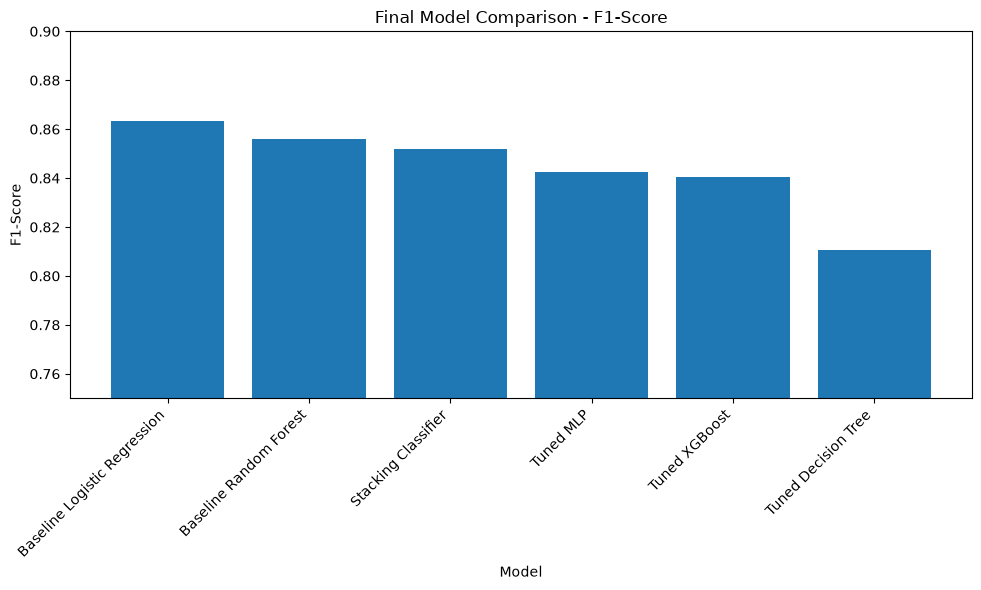

In [8]:
# Visualise the F1-Score of all final models

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    ranked_models["Model"],
    ranked_models["F1-Score"]
)

plt.title(
    "Final Model Comparison - F1-Score"
)

plt.xlabel("Model")
plt.ylabel("F1-Score")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0.75, 0.90)

plt.tight_layout()
plt.show()

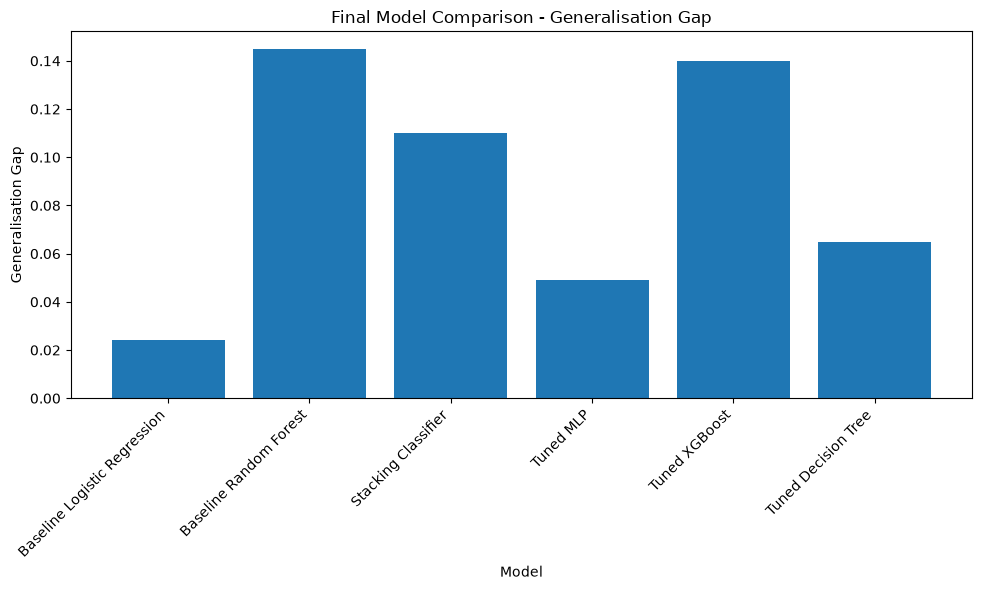

In [9]:
# Visualise the Generalisation Gap of all final models

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    ranked_models["Model"],
    ranked_models["Generalisation Gap"]
)

plt.title(
    "Final Model Comparison - Generalisation Gap"
)

plt.xlabel("Model")
plt.ylabel("Generalisation Gap")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [10]:
# Identify the best-performing model based on F1-Score

best_model_row = ranked_models.iloc[0]

best_model_name = best_model_row["Model"]
best_f1 = best_model_row["F1-Score"]
best_accuracy = best_model_row["Testing Accuracy"]
best_gap = best_model_row["Generalisation Gap"]

print("Best Performing Model")
print("=" * 50)

print("Model:", best_model_name)
print(f"Testing Accuracy: {best_accuracy:.4f}")
print(f"F1-Score: {best_f1:.4f}")
print(f"Generalisation Gap: {best_gap:.4f}")

Best Performing Model
Model: Baseline Logistic Regression
Testing Accuracy: 0.8633
F1-Score: 0.8635
Generalisation Gap: 0.0242


In [11]:
# Save the ranked final model comparison table

final_comparison_path = (
    RESULTS_PATH / "final_model_comparison.csv"
)

ranked_models.to_csv(
    final_comparison_path,
    index=True
)

print("Final model comparison saved successfully.")
print("Saved to:", final_comparison_path.resolve())

Final model comparison saved successfully.
Saved to: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\results\final_model_comparison.csv


In [12]:
# Load the selected Baseline Logistic Regression model

best_model = joblib.load(
    MODEL_PATH / "logistic_regression_baseline.pkl"
)

print("Baseline Logistic Regression model loaded successfully.")
print("Model type:", type(best_model))

Baseline Logistic Regression model loaded successfully.
Model type: <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [13]:
# Load the scaler and training feature names used by Logistic Regression

scaler = joblib.load(
    MODEL_PATH / "scaler.pkl"
)

X_train = pd.read_csv(
    DATA_PATH / "X_train.csv"
)

feature_names = X_train.columns.tolist()

print("Scaler loaded successfully.")
print("Number of features:", len(feature_names))

Scaler loaded successfully.
Number of features: 38


In [14]:
# Create the final deployment package for AquaSafe AI

class_names = best_model.classes_.tolist()

deployment_package = {
    "model": best_model,
    "scaler": scaler,
    "requires_external_scaling": True,
    "feature_names": feature_names,
    "class_names": class_names,
    "model_name": best_model_name,
    "evaluation": {
        "training_accuracy": float(
            best_model_row["Training Accuracy"]
        ),
        "testing_accuracy": float(
            best_model_row["Testing Accuracy"]
        ),
        "precision": float(
            best_model_row["Precision"]
        ),
        "recall": float(
            best_model_row["Recall"]
        ),
        "f1_score": float(
            best_model_row["F1-Score"]
        ),
        "generalisation_gap": float(
            best_model_row["Generalisation Gap"]
        )
    }
}

print("Deployment package created successfully.")
print("Selected Model:", deployment_package["model_name"])
print("External Scaling Required:",
      deployment_package["requires_external_scaling"])
print("Number of Features:",
      len(deployment_package["feature_names"]))
print("Classes:",
      deployment_package["class_names"])

Deployment package created successfully.
Selected Model: Baseline Logistic Regression
External Scaling Required: True
Number of Features: 38
Classes: ['High', 'Low', 'Medium']


In [15]:
# Save the final AquaSafe AI deployment package

deployment_path = (
    MODEL_PATH / "aquasafe_deployment_package.pkl"
)

joblib.dump(
    deployment_package,
    deployment_path
)

print("Deployment package saved successfully.")
print("Saved to:", deployment_path.resolve())

Deployment package saved successfully.
Saved to: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\aquasafe_deployment_package.pkl


In [16]:
# Reload and verify the saved AquaSafe AI deployment package

loaded_package = joblib.load(
    MODEL_PATH / "aquasafe_deployment_package.pkl"
)

print("Deployment package loaded successfully.")
print("=" * 50)

print("Model:", loaded_package["model_name"])
print("Model Type:", type(loaded_package["model"]).__name__)
print("Scaling Required:", loaded_package["requires_external_scaling"])
print("Number of Features:", len(loaded_package["feature_names"]))
print("Classes:", loaded_package["class_names"])

Deployment package loaded successfully.
Model: Baseline Logistic Regression
Model Type: LogisticRegression
Scaling Required: True
Number of Features: 38
Classes: ['High', 'Low', 'Medium']


In [17]:
# Test the final deployment workflow using one unseen test sample

X_test = pd.read_csv(
    DATA_PATH / "X_test.csv"
)

y_test = pd.read_csv(
    DATA_PATH / "y_test.csv"
).squeeze("columns")


# Select one unseen sample
sample_input = X_test.iloc[[0]]

# Keep the exact feature order used during training
sample_input = sample_input[
    loaded_package["feature_names"]
]


# Apply the saved scaler
scaled_sample = loaded_package["scaler"].transform(
    sample_input
)


# Generate the predicted class
sample_prediction = loaded_package["model"].predict(
    scaled_sample
)


# Generate prediction probabilities
sample_probabilities = loaded_package["model"].predict_proba(
    scaled_sample
)


print("Actual Risk Level:", y_test.iloc[0])
print("Predicted Risk Level:", sample_prediction[0])

print("\nPrediction Probabilities:")

for class_name, probability in zip(
    loaded_package["class_names"],
    sample_probabilities[0]
):
    print(
        f"{class_name}: {probability * 100:.2f}%"
    )

Actual Risk Level: Medium
Predicted Risk Level: Medium

Prediction Probabilities:
High: 18.42%
Low: 0.12%
Medium: 81.47%


In [18]:
# Verify the final files created by the model comparison notebook

files_to_check = [
    RESULTS_PATH / "final_model_comparison.csv",
    MODEL_PATH / "aquasafe_deployment_package.pkl"
]

print("Final Generated Files")
print("=" * 50)

for file_path in files_to_check:
    print(
        f"{file_path.name}: {file_path.exists()}"
    )

Final Generated Files
final_model_comparison.csv: True
aquasafe_deployment_package.pkl: True


## Conclusion

The final comparison included Logistic Regression, Decision Tree, Random Forest, XGBoost, MLP and the Stacking Classifier.

Baseline Logistic Regression achieved the strongest overall result with a testing accuracy of 86.33% and an F1-score of 86.35%. It also produced the smallest generalisation gap of 2.42%, showing more stable performance between the training and test datasets.

Although the Stacking Classifier combined several models and achieved a testing accuracy of 85.17%, it did not outperform Logistic Regression and showed a larger generalisation gap of 11.00%. This demonstrates that a more complex model does not always provide better performance for the available dataset.

Therefore, Baseline Logistic Regression was selected as the final deployment model for AquaSafe AI. The model was packaged together with the required scaler, feature names and class information, and the deployment workflow was successfully tested using an unseen test sample.